# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [30]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [32]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [33]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [34]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [35]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [36]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [37]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [38]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [39]:
# cantidad de nulos para users
# Cantidad de valores nulos por columna
print(users.isna().sum())

# Proporción de valores nulos por columna
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [40]:
# cantidad de nulos para usage
# Cantidad de valores nulos por columna
print(usage.isna().sum())

# Proporción de valores nulos por columna
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  Para el Dataset de users la columna city cuenta con 469 valores nulos y la columna churn_date con 3534. Representando un 12% y 88% respectivamente de los datos.
  Para el Dataset de usage las columnas que presentan valores nulos son date con 50, duration con 22076 y length con 17896, representando 0.00125%, 55% y 45% respectivamente
- Indica qué harías: ¿imputar, eliminar, ignorar?

  Para la columna date imputaría directamente los valores nulos a la madiana. Para la columna city investigaría primero a que se deben esos valores para saber si imputarlos o realmente dejan algún insight util para la empresa. Para el resto de columnas al ser un gran porcentaje las testearía primero que tanto afecta eliminarlas en el análisis antes de limpiar el dataset, ya que pertenecen a columnas muy importantes hay una alta probabilidad de marcarlos como NaaN.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [41]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Hay un total de 4000 usuarios, en este caso los demás calculos númericos son irrelevantes, ya que no estamos hablando de ninguna cantidad. Observando el la fila "min" podemos concluir que no hay valores negativos, por lo que la columna esta limpia.
- La columna `age` ... Hay también 4000 datos, de los cuales la media de edad entre los usuarios es de 34 años. Hay valores atipicos (Valores negativos) el dataset que hay que limpiar.

In [42]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Ninguna presenta un valor atipico, por lo que podemos concluir que dichas columnas estan limpias.
- Las columnas ... duration y length tienen también parecen estar limpias, sus medias son de 5.20 y 52.12, y las std son de 6.84 y 56.61.

In [43]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"Valores únicos de {columna}:")
    print(users[columna].unique())
    print()

Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']



- La columna `city` ... presenta un dato datipo de "?" hay que revisar de donde viene ese dato y decidir si se imputarla a NaaN o eliminara.
- La columna `plan` ... no presenta error alguno.

In [44]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` ... solo cuenta con dos categorías "call" y "type"


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [45]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [46]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [47]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... lo mas destacado es que se salta del año 2024 al 2026, no se tienen registros del 2025. También hay que señalar la enorme caída de cantidad de datos que se tiene del 2026.

In [48]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, ... El formato del año tiene un pequeño fallo al aparecer como "2024.0", al ser un año es incorecto que sea un número decimal. Se encontro que se tienen 50 registros sin año marcados como NaaN
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso: Hay que investigar a fondo las ausencias que tiene el dataset users en el año 2025, así como la caída tan abrupta de datos registrados entre el 2024 y el 2025.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) En el dataset usage aparece el año de 2024.0.
- ¿Qué harías con ellas? Hay que corregirlo a 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [49]:
# Calcular la mediana excluyendo el valor centinela -999
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar el centinela
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [50]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [51]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type', dropna=False)['duration'].apply(
    lambda columna: columna.isna().mean() * 100
)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [52]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type', dropna=False)['length'].apply(
    lambda columna: columna.isna().mean() * 100
)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se observa que los valores faltantes están directamente relacionados con el tipo de registro (type). En los registros de tipo call, duration no presenta valores nulos, mientras que length es nulo en aproximadamente el 99.93 % de los casos. Por el contrario, en los registros de tipo text, length no presenta valores nulos y duration es nulo en aproximadamente el 99.93 % de los casos. Puedo concluir que os valores faltantes no ocurren de forma aleatoria, sino que dependen de una variable observable (type), por lo que pueden considerarse MAR (Missing At Random). Recomiendo conservar los valores nulos en ambas columnas , ya que sustituirlos por 0, por la media u otro valor introduciría información artificial y podría distorsionar los análisis posteriores.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [53]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# Observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [54]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [55]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left',
    validate='one_to_one'
)

# Observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [56]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [57]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(
    normalize=True,
    dropna=False
).mul(100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

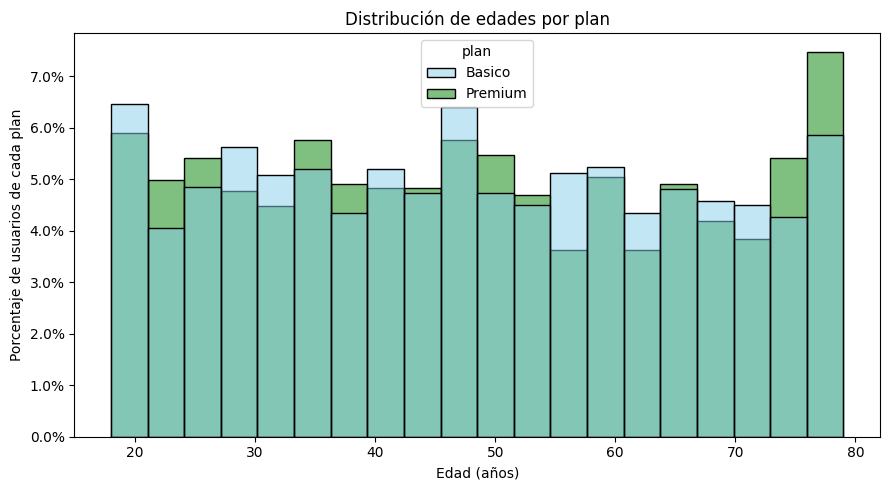

In [58]:
# Histograma para visualizar la edad (age)
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=user_profile, x='age', hue='plan',
    bins=20, palette=['skyblue', 'green'],
    stat='probability', common_norm=False, alpha=0.5
)

# Mostrar las proporciones como porcentajes: 0.10 → 10 %
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Distribución de edades por plan')
plt.xlabel('Edad (años)')
plt.ylabel('Porcentaje de usuarios de cada plan')
plt.tight_layout()
plt.show()

💡Insights: 
- Distribución ... La distribución de edades es bastante similar entre los planes Básico y Premium, sin una concentración clara en un grupo etario específico. Ambos planes tienen usuarios distribuidos a lo largo de casi todo el rango de edad, por lo que la edad no parece ser un factor determinante para diferenciar la elección del plan.

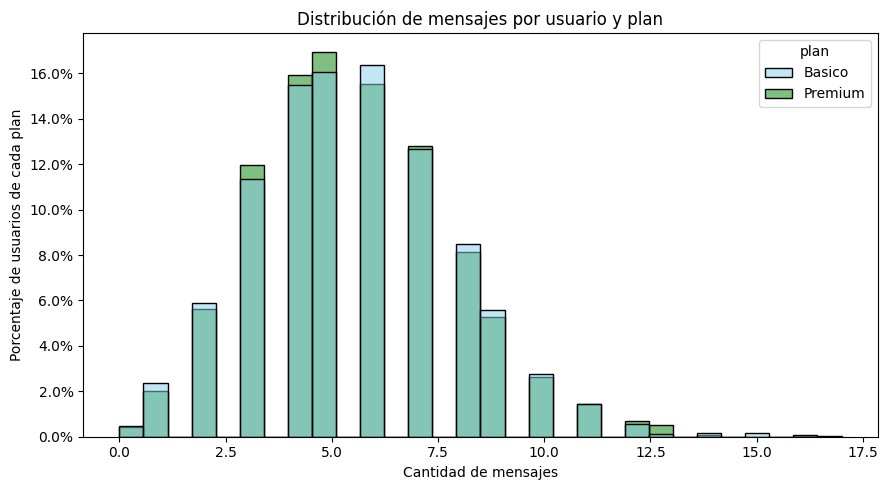

In [59]:
# Histograma para visualizar la cant_mensajes
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=user_profile, x='cant_mensajes', hue='plan',
    bins=30, palette=['skyblue', 'green'],
    stat='probability', common_norm=False, alpha=0.5
)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Distribución de mensajes por usuario y plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Porcentaje de usuarios de cada plan')
plt.tight_layout()
plt.show()

💡Insights: 
- La distribución está sesgada a la derecha y la mayoría de los usuarios envía entre 3 y 8 mensajes. Los planes Básico y Premium presentan un comportamiento muy similar, sin diferencias claras en el uso de mensajes.

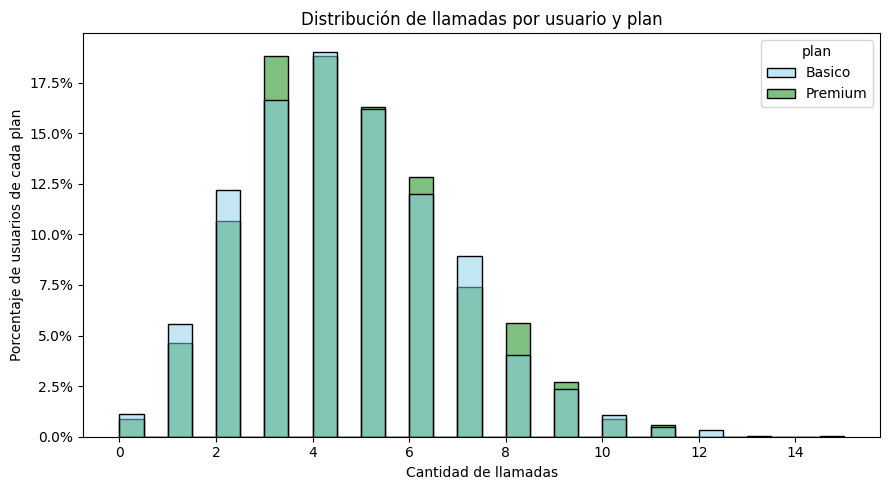

In [60]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=user_profile, x='cant_llamadas', hue='plan',
    bins=30, palette=['skyblue', 'green'],
    stat='probability', common_norm=False, alpha=0.5
)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Distribución de llamadas por usuario y plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Porcentaje de usuarios de cada plan')
plt.tight_layout()
plt.show()

💡Insights: 
- La mayoría de los usuarios realiza aproximadamente entre 2 y 6 llamadas, con una distribución también sesgada a la derecha. Ambos planes muestran patrones muy parecidos, por lo que el tipo de plan no parece determinar fuertemente la cantidad de llamadas.

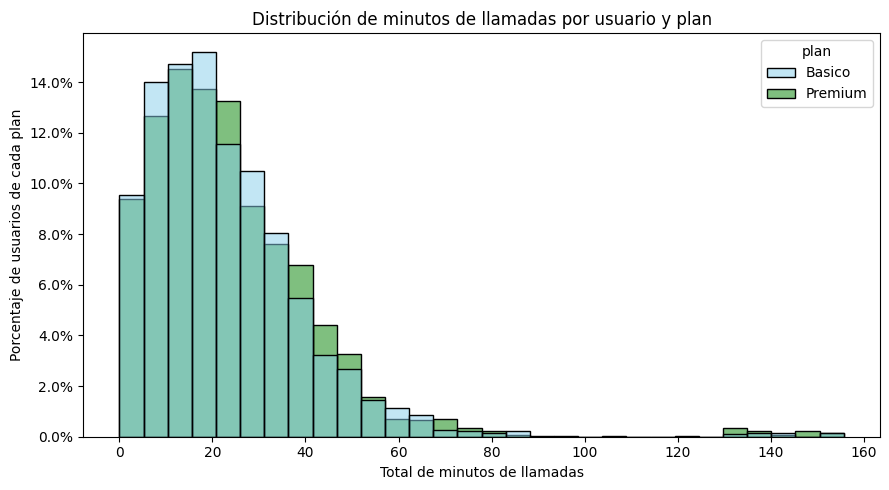

In [61]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=user_profile, x='cant_minutos_llamada', hue='plan',
    bins=30, palette=['skyblue', 'green'],
    stat='probability', common_norm=False, alpha=0.5
)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Distribución de minutos de llamadas por usuario y plan')
plt.xlabel('Total de minutos de llamadas')
plt.ylabel('Porcentaje de usuarios de cada plan')
plt.tight_layout()
plt.show()

💡Insights: 
- La mayor concentración de usuarios se encuentra en consumos relativamente bajos de minutos, mientras que pocos usuarios presentan consumos mucho mayores, generando una cola hacia la derecha. Las distribuciones de Básico y Premium se superponen ampliamente, aunque existen algunos usuarios con consumos elevados.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

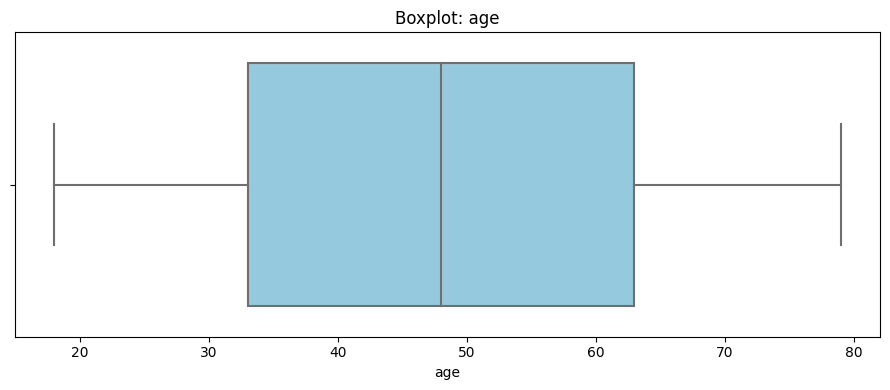

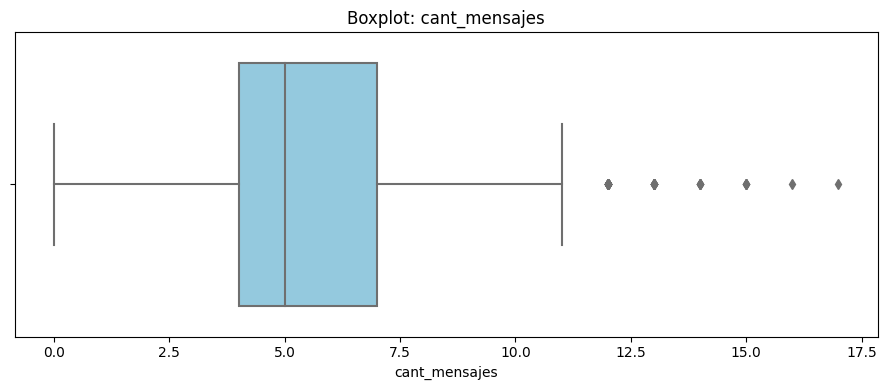

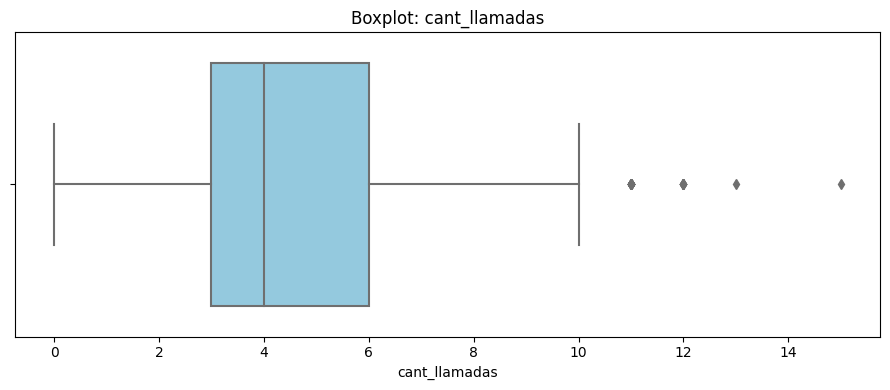

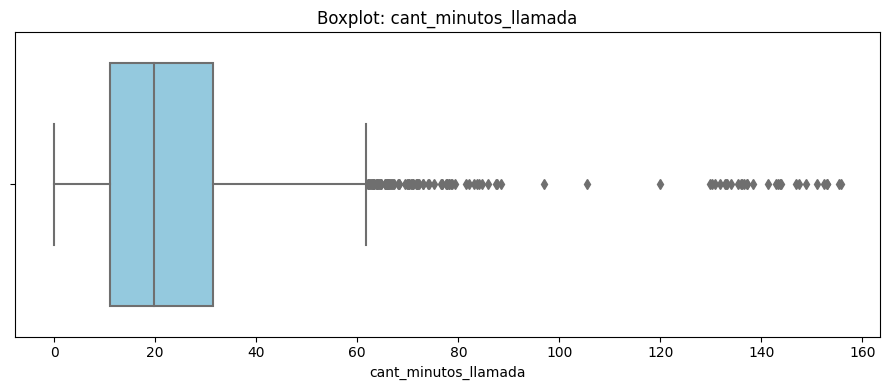

In [63]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [64]:
# Calcular límites con el método IQR
columnas_limites = []
resumen_iqr = []

for col in columnas_numericas:
    serie = user_profile[col].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    inferiores = (serie < limite_inferior).sum()
    superiores = (serie > limite_superior).sum()

    if inferiores + superiores > 0:
        columnas_limites.append(col)

    resumen_iqr.append({
        'variable': col,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'minimo': serie.min(),
        'maximo': serie.max(),
        'outliers_inferiores': inferiores,
        'outliers_superiores': superiores
    })

pd.DataFrame(resumen_iqr).set_index('variable').round(2)

,limite_inferior,limite_superior,minimo,maximo,outliers_inferiores,outliers_superiores
variable,,,,,,
age,-12.00,108.00,18.0,79.00,0,0
cant_mensajes,-0.50,11.50,0.0,17.00,0,46
cant_llamadas,-1.50,10.50,0.0,15.00,0,30
cant_minutos_llamada,-19.32,61.86,0.0,155.69,0,109


In [65]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
if columnas_limites:
    display(user_profile[columnas_limites].describe())
else:
    print('No se detectaron outliers con el criterio IQR.')

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [66]:
# Crear columna grupo_uso
llamadas = user_profile['cant_llamadas']
mensajes = user_profile['cant_mensajes']

# Categoría para el resto de casos
user_profile['grupo_uso'] = 'Alto uso'

# Ambos valores deben ser menores que 10
user_profile.loc[
    (llamadas < 10) & (mensajes < 10),
    'grupo_uso'
] = 'Uso medio'

# Ambos valores deben ser menores que 5
user_profile.loc[
    (llamadas < 5) & (mensajes < 5),
    'grupo_uso'
] = 'Bajo uso'

# Evitar clasificar como alto uso a usuarios con datos faltantes
user_profile.loc[
    llamadas.isna() | mensajes.isna(),
    'grupo_uso'
] = pd.NA

In [67]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [68]:
# Crear columna grupo_edad
edad = user_profile['age']

# Inicializar la columna sin clasificar
user_profile['grupo_edad'] = pd.NA

# Asignar los grupos por edad
user_profile.loc[edad < 30, 'grupo_edad'] = 'Joven'

user_profile.loc[
    (edad >= 30) & (edad < 60),
    'grupo_edad'
] = 'Adulto'

user_profile.loc[edad >= 60, 'grupo_edad'] = 'Adulto Mayor'

In [69]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

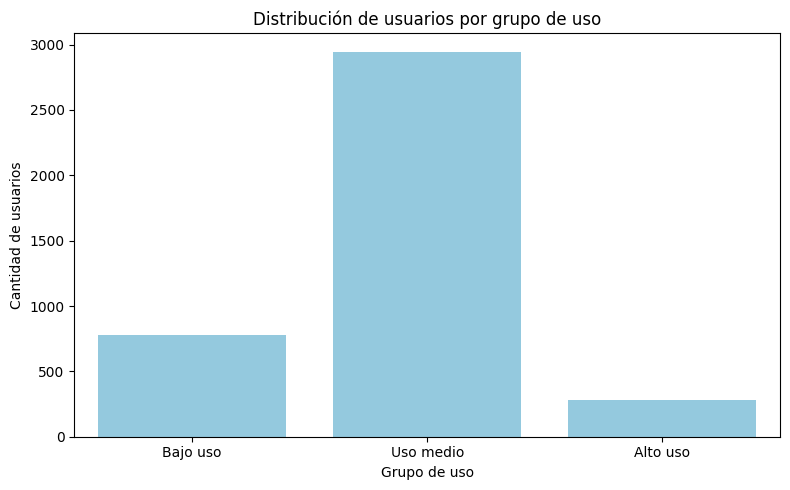

In [70]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    color='skyblue'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()

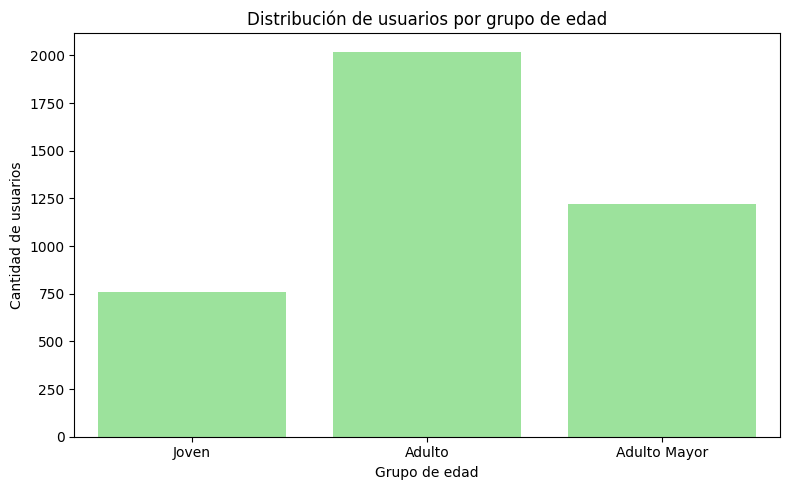

In [71]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    color='lightgreen'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En users se identificaron 55 edades con el sentinel -999, que fueron reemplazadas por la mediana. En city había 469 nulos (11.7%) y valores "?", que se estandarizaron como datos faltantes.
- churn_date presenta 3,534 nulos (88.4%), pero se conservaron porque pueden representar clientes que siguen activos. También se detectaron 40 fechas de registro fuera del periodo válido y 50 fechas inválidas en usage.
- Los nulos de duration (55.2%) y length (44.7%) se conservaron, ya que dependen del tipo de registro: las llamadas tienen duración y los mensajes tienen longitud.


🔍 **Segmentos por Edad**
- El segmento Adulto (30–59 años) concentra la mayor cantidad de clientes, seguido por los Adultos Mayores (60+); los jóvenes representan el grupo menos numeroso.
- Sin embargo, las distribuciones de edad son muy similares entre los planes Básico y Premium, por lo que la edad no parece ser un factor determinante en la elección del plan.


📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes pertenece al segmento de Uso medio, mientras que los clientes de Alto uso representan un grupo pequeño pero con una intensidad de consumo considerablemente mayor.
- Los planes Básico y Premium muestran distribuciones muy similares en mensajes, llamadas y minutos, lo que sugiere que el comportamiento real de consumo diferencia mejor a los clientes que el plan contratado.


➡️ Esto sugiere que ... Los clientes de alto uso son especialmente relevantes para ConnectaTel porque presentan mayores necesidades de comunicación y podrían tener mayor disposición a contratar planes con más capacidad. Al mismo tiempo, el gran volumen de clientes de uso medio constituye el segmento principal de la cartera y representa una oportunidad para estrategias de retención y venta adicional. También se encontraron patrones extremos de consumo: 46 usuarios superaron el límite esperado de mensajes, 30 el de llamadas y 109 el de minutos. Estos casos se conservaron porque no parecen errores, sino clientes reales con niveles de consumo elevados, que pueden representar oportunidades comerciales.


💡 **Recomendaciones**
- Desarrollar estrategias de upgrade para usuarios de uso medio que estén próximos a convertirse en clientes de alto consumo.
- Revisar la diferenciación entre Básico y Premium, ya que actualmente ambos grupos presentan patrones de uso muy similares; podría ser necesario reforzar los beneficios que justifican contratar el plan Premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`